### Generate offline samples
We have 1 dimension states, x \in [1,10] as integers
Generate 10e4 offline samples over them, those sampels are stored in a tensor format, each state corresponding to a one hot vector
center at 5 with gaussian noise
plot the vistiation percentage


State space: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of states: 10
Number of samples to generate: 100000
Sample statistics:
  Mean: 5.01
  Std: 1.97
  Min: 1
  Max: 10

One-hot tensor shape: torch.Size([100000, 10])
Example of first 5 samples:
  State 6: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  State 5: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  State 6: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  State 8: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  State 5: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

Visitation percentages:
  State 1: 4033 visits (4.03%)
  State 2: 6511 visits (6.51%)
  State 3: 12158 visits (12.16%)
  State 4: 17400 visits (17.40%)
  State 5: 19795 visits (19.79%)
  State 6: 17287 visits (17.29%)
  State 7: 12161 visits (12.16%)
  State 8: 6618 visits (6.62%)
  State 9: 2836 visits (2.84%)
  State 10: 1201 visits (1.20%)


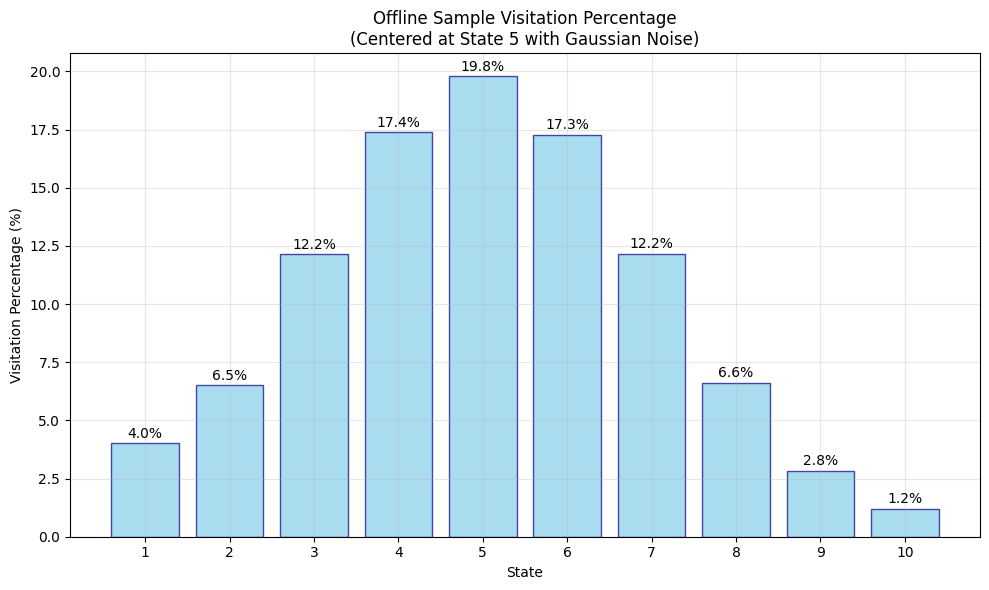


Stored variables:
  offline_samples: tensor of shape torch.Size([100000]) (integer states)
  offline_samples_onehot: tensor of shape torch.Size([100000, 10]) (one-hot encoded)
  visitation_percentages: dictionary with visitation percentages


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define the state space: integers from 1 to 10
state_space = list(range(1, 11))
num_states = len(state_space)
num_samples = int(10e4)  # 10^4 samples

print(f"State space: {state_space}")
print(f"Number of states: {num_states}")
print(f"Number of samples to generate: {num_samples}")

# Generate offline samples centered at 5 with Gaussian noise
center = 5
std_dev = 2.0  # Standard deviation for Gaussian noise

# Generate samples from Gaussian distribution centered at 5
raw_samples = np.random.normal(center, std_dev, num_samples)

# Clip and round to nearest integer in the range [1, 10]
discrete_samples = np.clip(np.round(raw_samples), 1, 10).astype(int)

print(f"Sample statistics:")
print(f"  Mean: {np.mean(discrete_samples):.2f}")
print(f"  Std: {np.std(discrete_samples):.2f}")
print(f"  Min: {np.min(discrete_samples)}")
print(f"  Max: {np.max(discrete_samples)}")

# Convert to tensor format with one-hot encoding
def states_to_onehot(states, num_states):
    """Convert integer states to one-hot vectors"""
    # Adjust states to be 0-indexed for one-hot encoding
    states_idx = states - 1
    one_hot = torch.zeros(len(states), num_states)
    one_hot[range(len(states)), states_idx] = 1
    return one_hot

# Convert discrete samples to one-hot vectors
offline_samples_onehot = states_to_onehot(discrete_samples, num_states)

print(f"\nOne-hot tensor shape: {offline_samples_onehot.shape}")
print(f"Example of first 5 samples:")
for i in range(5):
    state_val = discrete_samples[i]
    onehot_vec = offline_samples_onehot[i]
    print(f"  State {state_val}: {onehot_vec.numpy()}")

# Calculate visitation counts and percentages
visitation_counts = Counter(discrete_samples)
visitation_percentages = {state: (count / num_samples) * 100 
                         for state, count in visitation_counts.items()}

# Ensure all states are represented (even if count is 0)
for state in state_space:
    if state not in visitation_percentages:
        visitation_percentages[state] = 0.0

print(f"\nVisitation percentages:")
for state in state_space:
    count = visitation_counts.get(state, 0)
    percentage = visitation_percentages[state]
    print(f"  State {state}: {count} visits ({percentage:.2f}%)")

# Plot the visitation percentage
plt.figure(figsize=(10, 6))

states = list(visitation_percentages.keys())
percentages = list(visitation_percentages.values())

bars = plt.bar(states, percentages, alpha=0.7, color='skyblue', edgecolor='navy')
plt.xlabel('State')
plt.ylabel('Visitation Percentage (%)')
plt.title('Offline Sample Visitation Percentage\n(Centered at State 5 with Gaussian Noise)')
plt.xticks(state_space)
plt.grid(True, alpha=0.3)

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Store variables for potential future use
offline_samples = torch.tensor(discrete_samples, dtype=torch.long)
print(f"\nStored variables:")
print(f"  offline_samples: tensor of shape {offline_samples.shape} (integer states)")
print(f"  offline_samples_onehot: tensor of shape {offline_samples_onehot.shape} (one-hot encoded)")
print(f"  visitation_percentages: dictionary with visitation percentages")

### random initialize a NN with hiddend layer 32 32 taken the input and outptu a scalar

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self, input_size=10, hidden1=32, hidden2=32, output_size=1):
        """
        Simple Neural Network with two hidden layers
        
        Args:
            input_size: Size of input (number of states = 10)
            hidden1: Size of first hidden layer (32)
            hidden2: Size of second hidden layer (32)
            output_size: Size of output (scalar = 1)
        """
        super(SimpleNN, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        
        # Initialize weights randomly
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Initialize weights using Xavier/Glorot initialization"""
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        """Forward pass through the network"""
        # First hidden layer with ReLU activation
        x = F.relu(self.fc1(x))
        
        # Second hidden layer with ReLU activation
        x = F.relu(self.fc2(x))
        
        # Output layer (no activation for scalar output)
        x = self.fc3(x)
        
        return x

# Create the neural network
net = SimpleNN(input_size=num_states, hidden1=32, hidden2=32, output_size=1)

print("Neural Network Architecture:")
print(net)
print(f"\nNetwork parameters:")
total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params}")
print(f"  Trainable parameters: {trainable_params}")

# Test the network with some sample inputs
print(f"\nTesting the network:")
print(f"Input shape expected: {num_states} (one-hot vectors)")
print(f"Output shape: 1 (scalar)")

# Test with first 5 samples from our offline data
test_samples = offline_samples_onehot[:5]
print(f"\nTest input shape: {test_samples.shape}")

# Forward pass
with torch.no_grad():  # No need to compute gradients for testing
    outputs = net(test_samples)
    
print(f"Test output shape: {outputs.shape}")
print(f"Sample outputs:")
for i in range(5):
    state_val = offline_samples[i].item()
    onehot_input = test_samples[i]
    output_val = outputs[i].item()
    print(f"  State {state_val}: input {onehot_input.numpy()} -> output {output_val:.4f}")

# Display network weights for first layer (just a glimpse)
print(f"\nFirst layer weights shape: {net.fc1.weight.shape}")
print(f"First layer bias shape: {net.fc1.bias.shape}")
print(f"Sample of first layer weights (first 3 rows, all columns):")
print(net.fc1.weight[:3, :].detach().numpy())

Neural Network Architecture:
SimpleNN(
  (fc1): Linear(in_features=10, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Network parameters:
  Total parameters: 1441
  Trainable parameters: 1441

Testing the network:
Input shape expected: 10 (one-hot vectors)
Output shape: 1 (scalar)

Test input shape: torch.Size([5, 10])
Test output shape: torch.Size([5, 1])
Sample outputs:
  State 6: input [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] -> output 0.0430
  State 5: input [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] -> output -0.0891
  State 6: input [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] -> output 0.0430
  State 8: input [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] -> output -0.0892
  State 5: input [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] -> output -0.0891

First layer weights shape: torch.Size([32, 10])
First layer bias shape: torch.Size([32])
Sample of first layer weights (first 3 rows, all columns):
[[-0.01476852 -0.07886995 -0.31558692 -0